In [3]:
from operator import add
from typing import Annotated, List
from langgraph.graph import END, START, StateGraph
from langgraph.types import Send
from pydantic import BaseModel
from jinja2 import Template
import instructor
from ragu.pipeline import retrieve_data


class State(BaseModel):
  initial_query: str
  expanded_query: List[str] = []
  retrieved_recipes: Annotated[List[dict], add] = []
  recipes: List[dict] = []


class QueryExpandResponse(BaseModel):
    statements: List[str]


def query_expansion_node(state: State) -> dict:

    prompt_template = """You are a query expansion module in a recipe search assistant. Your job is to rewrite a user's question into distinct statements for semantic recipe search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture one separate dish or meal intent from the query.
- Use natural recipe-description language (meal type, cuisine, ingredients, cooking style, dietary constraints).
- Keep each constraint attached to the sub-intent it belongs to. In "high-protein breakfast and a quick low-carb dinner", quick applies only to dinner — not breakfast.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "I want a high-protein breakfast and a quick low-carb dinner"
Statements:
- "High-protein breakfast"
- "Quick low-carb dinner"

Question: "Can I get a creamy pasta dish and a light salad?"
Statements:
- "Creamy pasta dish"
- "Light salad"

Question: "I need a quick weeknight dinner under 400 calories"
Statements:
- "Quick weeknight dinner under 400 calories"

Question: "Do you have any pasta recipes?"
Statements:
- "Pasta recipes"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        max_tokens=1024,
        response_model=QueryExpandResponse
    )

    return {
        "expanded_query": response.statements
    }


def query_expand_conditional_edges(state: State) -> list:

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query
                }
            )
        )

    return send_messages


def retriever_node(state: dict) -> dict:
    retrieved = retrieve_data(state["query"], k=5)
    return {
        "retrieved_recipes": retrieved["recipes"]
    }


def aggregator_node(state: State) -> dict:
    seen = {}
    for r in state.retrieved_recipes:
        seen.setdefault(r["id"], r)

    return { "recipes": list(seen.values()) }


graph = (
  StateGraph(State)
  .add_node("query_expansion_node", query_expansion_node)
  .add_node("retriever_node", retriever_node)
  .add_node("aggregator_node", aggregator_node)
  .add_edge(START, "query_expansion_node")
  .add_conditional_edges("query_expansion_node", query_expand_conditional_edges)
  .add_edge("retriever_node", "aggregator_node")
  .add_edge("aggregator_node", END)
  .compile()
)

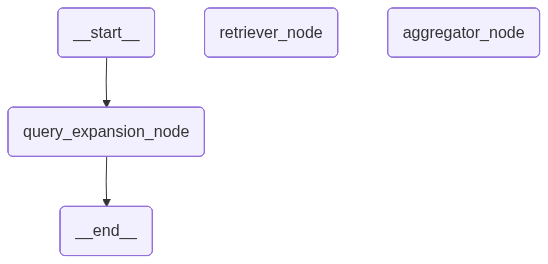

In [4]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
from langfuse.langchain import CallbackHandler

handler = CallbackHandler()
result = graph.invoke(
    {"initial_query": "I want a high-protein breakfast and a quick low-carb dinner"},
    config={"callbacks": [handler]},
) 

INFO:instructor.auto_client:Initializing openai provider with model gpt-5.4-mini
INFO:instructor.auto_client:Client initialized


In [9]:
result

{'initial_query': 'I want a high-protein breakfast and a quick low-carb dinner',
 'expanded_query': ['High-protein breakfast', 'Quick low-carb dinner'],
 'retrieved_recipes': [{'id': 246597,
   'name': 'Lower Carb Healthy Breakfast Parfait',
   'description': "This is our five-days a week breakfast and it has it all: it's low carb, hi-protein, a good source of fiber, dairy and antioxidants. It's creamy, sweet, crunchy and has great flavor. Ant it'll last you all morning. \r\nPS: The carb count the site has computed on this is \r\nnot accurate - the TVP has about 2 g. carbs, the flax seed meal is a wash, the coconut has about 2, the berries are about 6, the yogurt and cottage cheese about 8: and remember, the natural milk sugars in unsweetened yogurt don't impact blood sugars the way refined sugars do.",
   'text': "Lower Carb Healthy Breakfast Parfait\nThis is our five-days a week breakfast and it has it all: it's low carb, hi-protein, a good source of fiber, dairy and antioxidants. It